# Lab 3 — a baseline and a first network

**Deep Learning 2026, semester project. 90 minutes.**

By the end of this session you will have, in a public repository of your own:
a validation split that does not lie, a gradient-boosting baseline on seven
handcrafted features, a neural network you built and trained yourself on the
raw pixels, both logged to Weights & Biases, and an honest comparison of the
two. Every number on the board at the end comes from your laptop.

**How this notebook works.** The code lives in `src/`. This notebook imports
it, runs it and draws. A cell marked **TASK** names a file and a function:
you write it, come back, rerun the cell; `importlib.reload` picks up the edit
without restarting the kernel. There are six tasks, about 40 lines in total.

**Three stops, by the clock.** At **0:20**, **0:40** and **1:10** everyone
stops wherever they are. Each stop opens with a question on the slide that
you answer by show of hands *before* running the cell that settles it, then a
few minutes of talk, then the numbers from the room go on the board. If you have not finished a task
before a stop, the reference lines go on the screen at the stop and you paste
them; the code is the vehicle, the discussion is the point.

| time | part | what |
|---|---|---|
| 0:00–0:10 | 0 | the repository, public on GitHub; W&B |
| 0:10–0:20 | 1 | the data and the constant predictor — **stop 1** at 0:20 |
| 0:20–0:40 | 2 | TASK 1 the split; the baseline; what the network will see — **stop 2** at 0:40 |
| 0:40–1:10 | 3 | TASKS 2–6 the network, trained and logged — **stop 3** at 1:10 |
| 1:10–1:30 | 4 | three ways to fix it; compare, commit, push |

**Before the lab**, at home: the image is built, `scripts/check_env.py` ran,
the training data is downloaded from the private Kaggle dataset (the link is
on the slides and on Moodle; do not share it) and unzipped into `data/raw/`,
the caches are built with `python -m src.data.dataset`, and `pytest` shows
the two split tests failing and nothing else (they are TASK 1). If any of
these is not true now, say so immediately, not at 0:45.

**Running this notebook.** From the repository root, on your host:
`docker compose up lab`, then open http://localhost:8888 and this file under
`notebooks/`. In VS Code you can instead pick *Select Kernel → Existing
Jupyter Server* and enter `http://localhost:8888`. The README has the
details.

In [1]:
import importlib
import os
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import yaml
from PIL import Image

from src import config, evaluate
from src.data import splits
from src.data.dataset import build_cache, cache_dir, load_table, pixel_table
from src.features import handcrafted
from src.models import baseline
from dotenv import load_dotenv

load_dotenv()
%matplotlib inline
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.precision", 4)

print("project root ", config.ROOT)
print("torch        ", torch.__version__, "mps" if torch.mps.is_available() else "cpu, which is fine today")
print("wandb        ", "key set" if os.environ.get("WANDB_API_KEY") else "no key: runs will be anonymous",
      "/ mode", os.environ.get("WANDB_MODE", "online"))

cfg = yaml.safe_load(open(config.ROOT / "configs" / "lab3_mlp.yaml"))
df = load_table()
if not cache_dir(768).exists() or len(list(cache_dir(768).glob("*.jpg"))) < len(df):
    print("building the 768 px cache, this takes a few minutes ...")
    build_cache(df, 768)
y_all = df[config.TARGET].to_numpy()
ok_all = (df["eval_ok"] == 1).to_numpy()
print(len(df), "photographs,", df["page_id"].nunique(), "pages,", df["photographer"].nunique(),
      "photographers,", df["group_strict"].nunique(), "strict units,", ok_all.sum(), "scoreable")

project root  /Users/gaszneradam/Documents/BME/MSC/2_felev/deep_learning/dl2026-docphoto
torch         2.14.1 mps
wandb         key set / mode online
1841 photographs, 60 pages, 40 photographers, 6 strict units, 1794 scoreable


## Part 0 (0:00–0:10) — the repository and the tracker

**GitHub.** Your project repository starts now, and it is public from the
first commit.

1. On github.com: **New repository**, name `dl2026-docphoto`, **Public**, and
   *no* README, `.gitignore` or licence (this folder already has them).
2. In a terminal **on your host machine**, in this folder (not inside the
   container, which has no credentials):

```bash
git init
git add .
git commit -m "lab 3: start"
git branch -M main
git remote add origin https://github.com/<your-user>/dl2026-docphoto.git
git push -u origin main
```

3. Check that `git status` listed nothing under `data/`, `models/`, no `.env`
   and no `wandb/`. If it did, stop and ask before pushing.

**Weights & Biases.** Every training run today is logged. Your API key is at
https://wandb.ai/authorize (log in or sign up first; the free account is
enough). Copy `.env.example` to `.env`, paste the key after `WANDB_API_KEY=`,
and restart the container (`docker compose down`, then `docker compose up
lab`) so that it picks the key up. With a key, runs land in your account. If you did not, they land in an
anonymous account and each run prints a link you can claim later; that is
fine for today and wrong for the semester. The cell below just reports which.

**Why public.** The rules forbid sharing weights and predictions, not reading
each other's code, and a public commit history is your evidence that the work
happened as you went. **Why now.** A commit at the end of the hour means
something only if there was one at the beginning.

In [2]:
!cd {config.ROOT} && git log --oneline -3 && git remote -v
print("W&B:", "your account" if os.environ.get("WANDB_API_KEY") else "anonymous runs (claimable links)")

02cf2cc (HEAD -> main, origin/main) changed cuda to mps
5bce4b3 lab 3: baseline and first network
947f52c lab 3: start
origin	https://github.com/agaszner/dl2026-docphoto.git (fetch)
origin	https://github.com/agaszner/dl2026-docphoto.git (push)
W&B: your account


## Part 1 (0:10–0:20) — the data and the constant predictor

One row per photograph. `usability = 1 - CER` is the target. The columns from
`page_id` to `photographer` describe the page and the person; they exist for
splitting and for slicing the error, and a test image has none of them.
`eval_ok = 0` marks 47 heavily downscaled uploads: train on them if you like,
never measure on them.

,image_id,usability,cer,group,group_strict,page_id,layout_id,family,lang,font,size_pt,photographer,eval_ok,path
0,ph_003d3df3,0.9979,0.0021,15,8,77,38,prose,en,LBSans,13.0,P112,1,/Users/gaszneradam/Documents/BME/MSC/2_felev/d...
1,ph_00711a1c,0.3782,0.6218,1,1,2,1,sparse,hu,DVSerif,11.5,P122,1,/Users/gaszneradam/Documents/BME/MSC/2_felev/d...
2,ph_0088de0d,0.9728,0.0272,15,8,78,39,prose,hu,DVSansC,7.5,P136,1,/Users/gaszneradam/Documents/BME/MSC/2_felev/d...
3,ph_00bc1094,0.9355,0.0645,15,8,76,38,prose,hu,LBSans,13.0,P136,1,/Users/gaszneradam/Documents/BME/MSC/2_felev/d...
4,ph_00d63158,0.2540,0.7460,14,8,72,36,prose,hu,LBSerif,9.0,P121,1,/Users/gaszneradam/Documents/BME/MSC/2_felev/d...


median 0.815   above 0.95: 25.1%   below 0.5: 17.2%


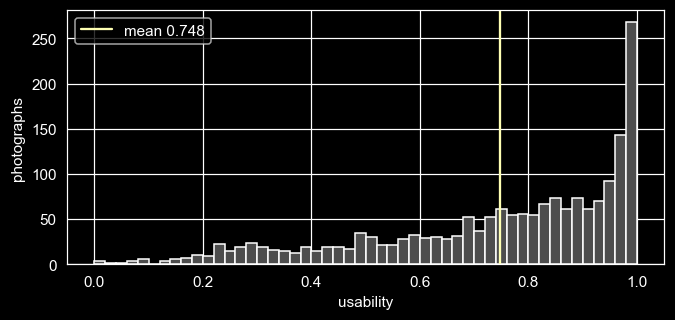

In [3]:
display(df.head())
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(y_all, bins=50, color="0.3")
ax.axvline(y_all.mean(), color="C1", label=f"mean {y_all.mean():.3f}")
ax.set_xlabel("usability"); ax.set_ylabel("photographs"); ax.legend()
print(f"median {np.median(y_all):.3f}   above 0.95: {np.mean(y_all > 0.95):.1%}   below 0.5: {np.mean(y_all < 0.5):.1%}")

### Stop 1 (0:20) — where the error lives

The first model ignores the image and predicts the mean for every photograph.
Its RMSE is the number every other model is measured against. The cell
splits the photographs into four bands of usability and shows what share of
the constant predictor's *squared* error each band contributes.

> **Stop.** Hands up: the question is on the slide. Answer it before you run
> the next cell.

In [4]:
const_all = np.full(len(df), y_all[ok_all].mean())
print(f"constant predictor, all scoreable rows: RMSE {evaluate.rmse(y_all[ok_all], const_all[ok_all]):.4f}")

bands = pd.cut(df[config.TARGET], [0, 0.5, 0.8, 0.95, 1.0001], right=False)
se = pd.Series((y_all - const_all) ** 2, index=df.index)
pd.DataFrame({"rows": bands.value_counts(sort=False),
              "share of rows": bands.value_counts(sort=False, normalize=True),
              "share of squared error": se.groupby(bands, observed=False).sum() / se.sum()})

constant predictor, all scoreable rows: RMSE 0.2303


,rows,share of rows,share of squared error
usability,,,
"[0.0, 0.5)",316,0.1716,0.6031
"[0.5, 0.8)",562,0.3053,0.0750
"[0.8, 0.95)",501,0.2721,0.0841
"[0.95, 1.0)",462,0.2510,0.2378


> **Your note** (one or two sentences, before the stop):
>
> A, because the mean is the furthest from the range 0-0.5

A thumbnail hides what the label sees. The best and the worst photograph of
the page with the widest label spread: the whole frame, and a crop from the
middle of the 2048 px original.

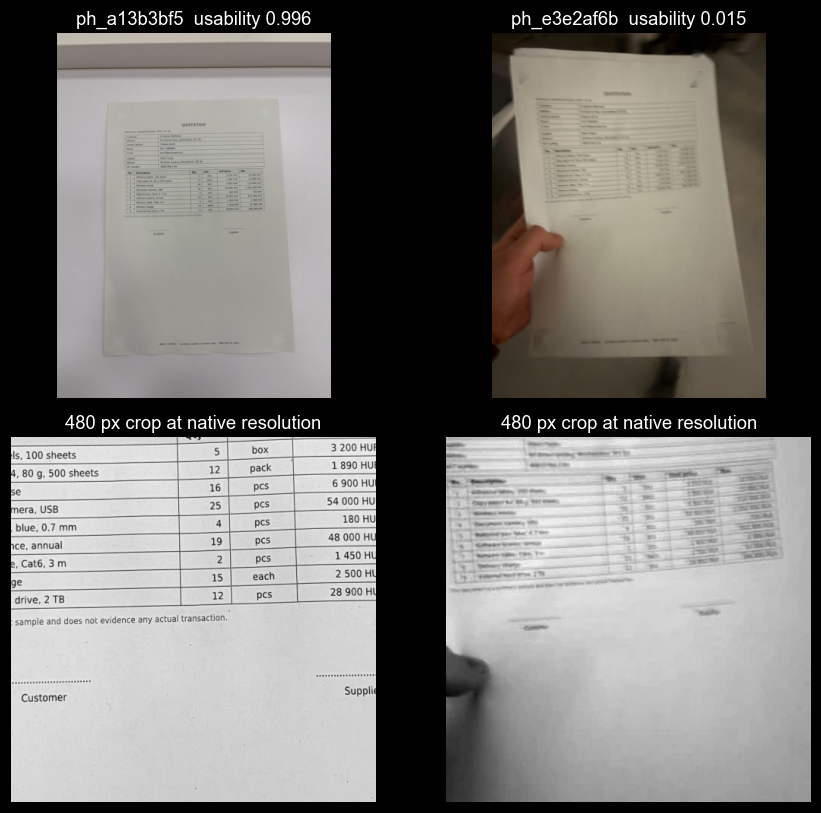

In [5]:
def show_pair(ids, labels, crop=480):
    fig, axes = plt.subplots(2, len(ids), figsize=(4.2 * len(ids), 7.5))
    for j, (i, lab) in enumerate(zip(ids, labels, strict=True)):
        full = Image.open(df.set_index("image_id").loc[i, "path"])
        small = full.copy(); small.thumbnail((384, 384))
        cx, cy = full.width // 2, full.height // 2
        axes[0, j].imshow(small); axes[0, j].set_title(f"{i}  usability {lab:.3f}")
        axes[1, j].imshow(full.convert("L").crop((cx - crop // 2, cy - crop // 2, cx + crop // 2, cy + crop // 2)), cmap="gray")
        axes[1, j].set_title(f"{crop} px crop at native resolution")
        for a in axes[:, j]:
            a.axis("off")
    plt.tight_layout()

spread = df.groupby("page_id")[config.TARGET].agg(["min", "max", "count"])
page = (spread["max"] - spread["min"])[spread["count"] >= 10].idxmax()
rows = df[df["page_id"] == page].sort_values(config.TARGET)
show_pair([rows.iloc[-1]["image_id"], rows.iloc[0]["image_id"]], [rows.iloc[-1][config.TARGET], rows.iloc[0][config.TARGET]])

## Part 2 (0:20–0:40) — the split, the baseline, the input

### TASK 1 — the split

Open `src/data/splits.py` and write `build_splits`. It holds out whole units
of `group_strict`: no page, no photographer and no document layout of the
validation side appears on the training side. The docstring is the contract,
and it prescribes the procedure step by step so that everyone in the room
holds out the same unit; `tests/test_splits.py` is the check. About ten
lines. Then run the cell: it asserts the split, shows which document
families ended up on which side, and runs the tests.

**Why not at random, and why `group_strict` and not `group`.** The same page
appears in dozens of photographs, each photographer's photos share a phone
and a room, and every layout exists in a Hungarian and an English version
typeset identically. We scored one model, a ResNet-18 at 768 px, four ways on
this data:

| validation scheme | RMSE |
|---|---|
| random 5-fold | 0.113 |
| folds by `group` (no page, no photographer twice) | 0.136 |
| folds by `group_strict` (also no layout twice) | 0.143 |
| the competition's held-out test set | **0.148** |

The random split is a fifth too good. `group` is still 8 % too good: the two
language versions of a layout sit in neighbouring groups, and the network
recognises the layout. `group_strict` lands on the test, which was cut the
same way.

**Six units is not many.** The training set has six strict units of ten pages
each, and each covers one or two document families; two of them are the only
source of their family. Which unit is held out is therefore a decision, not a
draw. The split has its own seed in the config, separate from the model's,
and it holds out unit 4.

In [6]:
importlib.reload(splits)
SPLIT = cfg["split"]
train_idx, val_idx = splits.build_splits(df, group_column=SPLIT["group_column"],
                                         val_fraction=SPLIT["val_fraction"], seed=SPLIT["seed"])
train_df, val_df = df.iloc[train_idx], df.iloc[val_idx]
ok = (val_df["eval_ok"] == 1).to_numpy()
y_val = val_df[config.TARGET].to_numpy()
prior = float(train_df[config.TARGET].mean())

assert len(set(train_idx) & set(val_idx)) == 0 and len(train_idx) + len(val_idx) == len(df)
for col in ("group_strict", "layout_id", "page_id", "photographer"):
    assert not set(train_df[col]) & set(val_df[col]), f"a {col} is on both sides"
val_units = sorted(int(u) for u in val_df["group_strict"].unique())
print(f"train {len(train_df)} rows, strict units {sorted(int(u) for u in train_df['group_strict'].unique())}")
print(f"val   {len(val_df)} rows ({len(val_df) / len(df):.0%}), strict units {val_units}, "
      f"{val_df['page_id'].nunique()} pages, {ok.sum()} scoreable")
if val_units != [4]:
    print("NOTE: the room holds out strict unit [4]. Your split is valid, but your numbers will not be "
          "comparable with the board: check steps 1 to 3 of the docstring.")

side = np.where(np.isin(np.arange(len(df)), val_idx), "validation", "training")
display(pd.crosstab(df["family"], [df["group_strict"].rename("strict unit"), pd.Series(side, name="side")]))

RESULTS = {"constant": evaluate.rmse(y_val[ok], np.full(ok.sum(), prior))}
print(f"constant predictor on this validation set: RMSE {RESULTS['constant']:.4f}")
!cd {config.ROOT} && pytest -q

train 1461 rows, strict units [1, 3, 5, 6, 8]
val   380 rows (21%), strict units [4], 10 pages, 380 scoreable


strict unit,1,3,4,5,6,8
side,training,training,validation,training,training,training
family,,,,,,
prose,0,0,0,0,0,285
receipt,0,0,157,236,0,0
sparse,241,0,0,0,0,0
table,0,373,223,0,0,0
twocol,0,0,0,42,284,0


constant predictor on this validation set: RMSE 0.2362
...                                                                      [100%]


### The baseline

Seven handcrafted features, given, computed on the 768 px cache: two
sharpness measures, three exposure and contrast measures, and two tile-wise
ones that take the worst tile instead of the average. `src/models/baseline.py`
fits gradient boosting on them. This is the model family the instructor's
leaderboard baseline comes from, and the number your network has to beat.

7 features for 1841 photographs in 3 s: ['lap_var', 'dark_frac', 'tenengrad', 'contrast_p95_p5', 'bright_frac', 'tile_lapvar_min', 'tile_dark_max']
baseline RMSE 0.1732   (constant 0.2362)


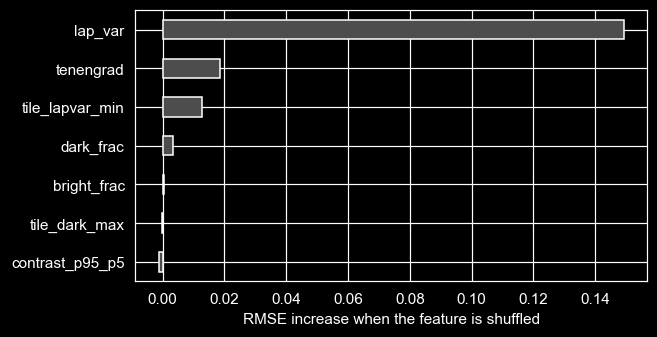

In [7]:
t0 = time.time()
F = handcrafted.feature_table(df)
print(f"{F.shape[1]} features for {len(F)} photographs in {time.time() - t0:.0f} s: {list(F.columns)}")

gbm = baseline.fit_baseline(F.iloc[train_idx], train_df[config.TARGET].to_numpy())
pred_gbm = baseline.predict_baseline(gbm, F.iloc[val_idx])
RESULTS["gradient boosting, 7 features"] = evaluate.rmse(y_val[ok], pred_gbm[ok])
print(f"baseline RMSE {RESULTS['gradient boosting, 7 features']:.4f}   (constant {RESULTS['constant']:.4f})")

imp = baseline.importance(gbm, F.iloc[val_idx][ok], y_val[ok])
imp.plot.barh(figsize=(6, 3.2), color="0.3"); plt.gca().invert_yaxis()
plt.xlabel("RMSE increase when the feature is shuffled"); plt.show()

### How far to trust one number

Everything in this notebook is measured on **one** validation split: one
strict unit, ten pages of two document families, a few hundred scoreable
photographs. That is one sample of what a validation set could have been.
Hold out another unit and every number here moves, by more than the gap
between two reasonable models: for the gradient-boosting baseline the six
units score anywhere between 0.16 and 0.24.

The proper way to compare two models on a dataset this size:

1. **Grouped k-fold.** Hold out each strict unit in turn. Train one model
   per unit and predict every photograph with the model that never saw its
   unit. These *out-of-fold* predictions cover all photographs, so the score
   rests on the whole dataset instead of a fifth.
2. **The same rows for both models.** Compare two models on identical
   photographs, never on two different validation sets: a harder set loses
   whichever model is better.
3. **A paired bootstrap over pages.** To ask whether model A really beats
   model B, resample *pages* with replacement (photographs of one page are
   not independent), recompute the RMSE difference on each resample, and look
   at how often the sign flips. On this data a difference under about 0.01
   RMSE is usually not resolvable from a single split.

It costs k times the training, which is nothing for gradient boosting and a
few seconds for today's network. Treat every number below as one draw, and
read gaps smaller than 0.01 as ties.

### The input of the network

The network of this session is a multilayer perceptron, and its input is the
photograph itself: reduced to 64 × 64 grey levels, flattened to a vector of
4096 numbers. No features, no rectification. The cell shows eight
photographs exactly as the network will receive them, ordered by label.

pixel table (1841, 4096), 30 MB, in 0.0 s


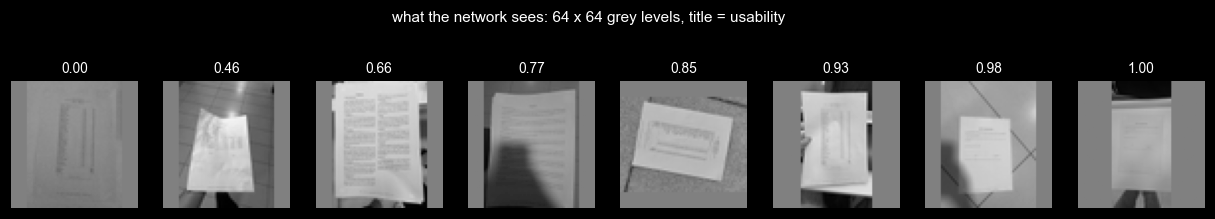

In [8]:
cfg = yaml.safe_load(open(config.ROOT / "configs" / "lab3_mlp.yaml"))
SIZE = cfg["data"]["pixel_size"]
t0 = time.time()
X = pixel_table(df, SIZE)
print(f"pixel table {X.shape}, {X.nbytes / 1e6:.0f} MB, in {time.time() - t0:.1f} s")

order = np.argsort(y_all)
picks = order[np.linspace(0, len(order) - 1, 8).astype(int)]
fig, axes = plt.subplots(1, 8, figsize=(14, 2.2))
for ax, i in zip(axes, picks, strict=True):
    ax.imshow(X[i].reshape(SIZE, SIZE), cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"{y_all[i]:.2f}", fontsize=9); ax.axis("off")
plt.suptitle(f"what the network sees: {SIZE} x {SIZE} grey levels, title = usability", y=1.05, fontsize=10)
plt.show()

### Stop 2 (0:40) — two predictions

> **Stop.** Hands up: two questions are on the slides. Answer both before you
> run the next cell, and write your answer to the second one down: it comes
> back at stop 3.

In [9]:
A4_LONG_MM, PT_MM = 297.0, 25.4 / 72
for size in (64, 128, 768, 2048):
    print(f"{size:5d} px long side:  a 9 pt letter is about {9 * PT_MM * size / A4_LONG_MM:5.2f} px tall")
print(f"\ninputs per photograph {SIZE * SIZE},  training photographs {len(train_idx)}")

   64 px long side:  a 9 pt letter is about  0.68 px tall
  128 px long side:  a 9 pt letter is about  1.37 px tall
  768 px long side:  a 9 pt letter is about  8.21 px tall
 2048 px long side:  a 9 pt letter is about 21.89 px tall

inputs per photograph 4096,  training photographs 1461


## Part 3 (0:40–1:10) — the network

### TASK 2 — the model

Open `src/models/mlp.py` and write `MLP`: one Linear + nonlinearity + Dropout
block per entry of `hidden`, an output in [0, 1], shape `(batch,)`. The
docstring names the decisions: where dropout goes, how the output is
bounded, and what the output bias starts at (`prior` is the training mean,
passed to you for a reason). The check cell runs eight rows through the
untrained network; if your head starts where the data is, the outputs sit at
the prior. Look at the parameter count it prints.

In [10]:
from src.models import mlp
importlib.reload(mlp)

net = mlp.MLP(in_dim=X.shape[1], hidden=cfg["model"]["hidden"], dropout=cfg["model"]["dropout"], prior=prior).eval()
with torch.no_grad():
    out = net(torch.randn(8, X.shape[1]))
assert out.shape == (8,), f"forward must return shape (batch,), got {tuple(out.shape)}"
assert float(out.min()) >= 0 and float(out.max()) <= 1, "outputs must lie in [0, 1]"
n_params = sum(p.numel() for p in net.parameters())
print(f"parameters        {n_params:,}  =  {n_params / len(train_idx):.0f} per training photograph")
print(f"untrained outputs {np.round(out.numpy(), 3)}")
print(f"training prior    {prior:.3f}")
print(net)

parameters        1,065,345  =  729 per training photograph
untrained outputs [0.75  0.78  0.763 0.784 0.771 0.76  0.782 0.782]
training prior    0.759
MLP(
  (body): Sequential(
    (0): Linear(in_features=4096, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
  )
  (head): Linear(in_features=64, out_features=1, bias=True)
)


### TASKS 3–6 — the training machinery

Open `src/train.py`. The pixel standardisation, the epoch loop with its W&B
logging and the checkpoint are written. Four functions are not, and the loop
calls them in this order:

| | function | contract |
|---|---|---|
| TASK 3 | `make_optimizer` | the optimiser from `lr` and `weight_decay` in the config |
| TASK 4 | `train_epoch` | one pass in shuffled minibatches, one optimiser step per batch, returns the mean loss |
| TASK 5 | `predict` | outputs for every row as a numpy array, eval mode, no gradients |
| TASK 6 | `validate` | RMSE on the scoreable validation rows |

About 20 lines together. Read the given part once before you write yours:
it shows exactly how each is called. Then train. The run prints its W&B
page; open it, the curves are there as they happen.

In [11]:
from src import train as trainer
importlib.reload(trainer)

t0 = time.time()
run = trainer.train_mlp(cfg, X, df, train_idx, val_idx)
h = run["history"]
RESULTS[f"mlp on {SIZE}x{SIZE} pixels, last epoch"] = h["val_rmse"].iloc[-1]
print(f"\n{time.time() - t0:.0f} s   val RMSE: last epoch {h['val_rmse'].iloc[-1]:.4f}, "
      f"best {h['val_rmse'].min():.4f} at epoch {int(h['val_rmse'].idxmin()) + 1}   run page: {run['url']}")

wandb: Using wandb-core as the SDK backend. Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: agaszner (agaszner-agaszner). Use `wandb login --relogin` to force relogin
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core


lab3_mlp: 1461 train / 380 val rows, 4096 inputs, 1,065,345 parameters, mps
epoch   1  train loss 0.0529  train RMSE 0.2192  val RMSE 0.2349
epoch  10  train loss 0.0383  train RMSE 0.1835  val RMSE 0.2420
epoch  20  train loss 0.0272  train RMSE 0.1482  val RMSE 0.2345
epoch  30  train loss 0.0216  train RMSE 0.1271  val RMSE 0.2404
epoch  40  train loss 0.0178  train RMSE 0.1105  val RMSE 0.2373
epoch  50  train loss 0.0158  train RMSE 0.1006  val RMSE 0.2475
epoch  60  train loss 0.0141  train RMSE 0.0995  val RMSE 0.2511


wandb: WARNING Unable to render Widget, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core



15 s   val RMSE: last epoch 0.2511, best 0.2248 at epoch 17   run page: https://wandb.ai/agaszner-agaszner/dl2026-docphoto/runs/xap5hnzu


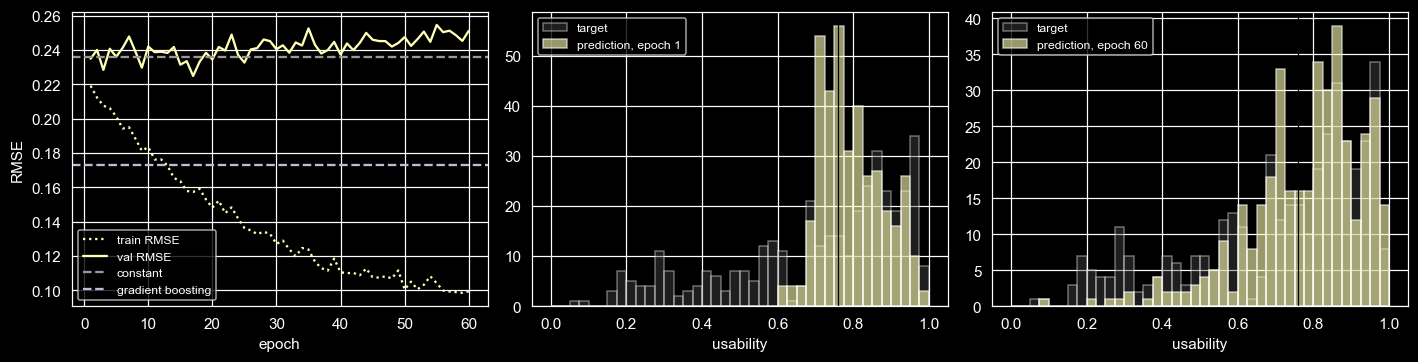

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
axes[0].plot(h["epoch"], h["train_rmse"], ":", color="C1", label="train RMSE")
axes[0].plot(h["epoch"], h["val_rmse"], "-", color="C1", label="val RMSE")
axes[0].axhline(RESULTS["constant"], color="0.6", ls="--", label="constant")
axes[0].axhline(RESULTS["gradient boosting, 7 features"], color="C2", ls="--", label="gradient boosting")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("RMSE"); axes[0].legend(fontsize=8)
bins = np.linspace(0, 1, 41)
first, last = min(run["snapshots"]), max(run["snapshots"])
for ax, ep in zip(axes[1:], (first, last), strict=True):
    ax.hist(y_val[ok], bins, alpha=0.4, color="0.3", label="target")
    ax.hist(run["snapshots"][ep][ok], bins, alpha=0.6, color="C1", label=f"prediction, epoch {ep}")
    ax.axvline(prior, color="k", lw=0.8); ax.legend(fontsize=8); ax.set_xlabel("usability")
plt.tight_layout(); plt.show()

### Stop 3 (1:10) — the result against the prediction

Your answer from stop 2, the curves and the two histograms side by side.
Where did the validation curve go after its minimum, and where did the
training curve go? What exactly has the network learned about the training
photographs, and why is that worth nothing on photographs of pages it has
not seen?

> **Stop.** Hands up: the question is on the slide. Answer it before you run
> the next cell.

## Part 4 (1:10–1:30) — three ways to fix it, then compare and commit

One change per run, each logged to W&B under its own name. This is what the
tracker is for: in December you will have a hundred of these and no memory
of which was which.

wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render Widget, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.core
wandb: WARNING Unable to render HTML, can't import display from ipython.co

,"val RMSE, last epoch","val RMSE, best epoch",best epoch,"train RMSE, last epoch"
"as configured (64 px, dropout 0.3)",0.2511,0.2248,17.0,0.0995
no dropout,0.2639,0.2279,1.0,0.0749
dropout 0.5,0.2488,0.2246,31.0,0.1311
128 px input,0.2456,0.2219,17.0,0.1019


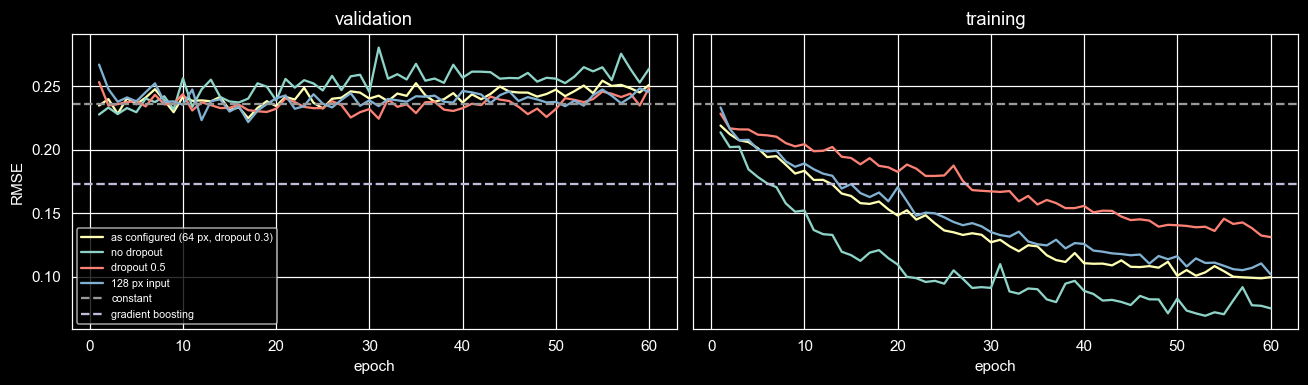

In [13]:
def variant(name, **changes):
    c = yaml.safe_load(open(config.ROOT / "configs" / "lab3_mlp.yaml"))
    c["name"] = name
    for key, value in changes.items():
        section, field = key.split("__")
        c[section][field] = value
    Xv = pixel_table(df, c["data"]["pixel_size"])
    return trainer.train_mlp(c, Xv, df, train_idx, val_idx, log=lambda *a: None)

runs = {
    f"as configured ({SIZE} px, dropout {cfg['model']['dropout']})": run,
    "no dropout": variant("lab3_mlp_do0.0", model__dropout=0.0),
    "dropout 0.5": variant("lab3_mlp_do0.5", model__dropout=0.5),
    "128 px input": variant("lab3_mlp_128px", data__pixel_size=128),
}
ablation = pd.DataFrame({name: {"val RMSE, last epoch": r["history"]["val_rmse"].iloc[-1],
                                "val RMSE, best epoch": r["history"]["val_rmse"].min(),
                                "best epoch": int(r["history"]["val_rmse"].idxmin()) + 1,
                                "train RMSE, last epoch": r["history"]["train_rmse"].iloc[-1]}
                         for name, r in runs.items()}).T
display(ablation)
RESULTS["mlp, best epoch of the best variant (peeking)"] = ablation["val RMSE, best epoch"].min()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6), sharey=True)
for (name, r), c in zip(runs.items(), ("C1", "C0", "C3", "C4"), strict=True):
    hh = r["history"]
    axes[0].plot(hh["epoch"], hh["val_rmse"], color=c, label=name)
    axes[1].plot(hh["epoch"], hh["train_rmse"], color=c, label=name)
for ax, title in zip(axes, ("validation", "training"), strict=True):
    ax.axhline(RESULTS["constant"], color="0.6", ls="--", label="constant")
    ax.axhline(RESULTS["gradient boosting, 7 features"], color="C2", ls="--", label="gradient boosting")
    ax.set_xlabel("epoch"); ax.set_title(title)
axes[0].set_ylabel("RMSE"); axes[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

What the first layer looks at. Each of its units has one weight per input
pixel, so a unit can be drawn as a 64 × 64 image: bright where a bright pixel
pushes the unit up, dark where it pushes it down. The eight units with the
largest weights:

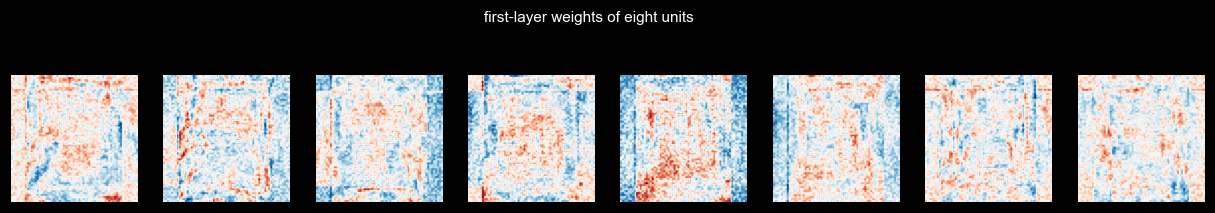

In [14]:
first_layer = next(m for m in run["model"].modules() if isinstance(m, torch.nn.Linear))
W = first_layer.weight.detach().cpu().numpy()
top = np.argsort(-np.linalg.norm(W, axis=1))[:8]
fig, axes = plt.subplots(1, 8, figsize=(14, 2.1))
for ax, u in zip(axes, top, strict=True):
    lim = np.abs(W[u]).max()
    ax.imshow(W[u].reshape(SIZE, SIZE), cmap="RdBu", vmin=-lim, vmax=lim); ax.axis("off")
plt.suptitle("first-layer weights of eight units", y=1.05, fontsize=10); plt.show()

### The comparison

The same validation rows, the same metric, every model of the hour, the
error by document family, and the network's five worst photographs.

,val RMSE (eval_ok rows),vs constant
constant,0.2362,0.0000
"gradient boosting, 7 features",0.1732,0.2665
"mlp on 64x64 pixels, last epoch",0.2511,-0.0634
"mlp, best epoch of the best variant (peeking)",0.2219,0.0605


,gradient boosting,mlp on pixels,n
family,,,
table,0.2055,0.2915,223
receipt,0.1125,0.1787,157


,image_id,usability,pred,error,family,font,size_pt,photographer
1062,ph_97dfc4c9,0.2767,0.9802,0.7035,table,LBSans,8.0,P128
1741,ph_f4c8ee37,0.1538,0.8496,0.6958,table,DVSansC,7.5,P138
629,ph_5aec8efd,0.2069,0.8892,0.6823,table,LBSans,8.0,P138
1825,ph_fdef9e63,0.1871,0.8640,0.6769,table,DVSansC,7.5,P128
1709,ph_f0ea5e5e,0.2174,0.8873,0.6699,table,DVSansC,7.5,P143


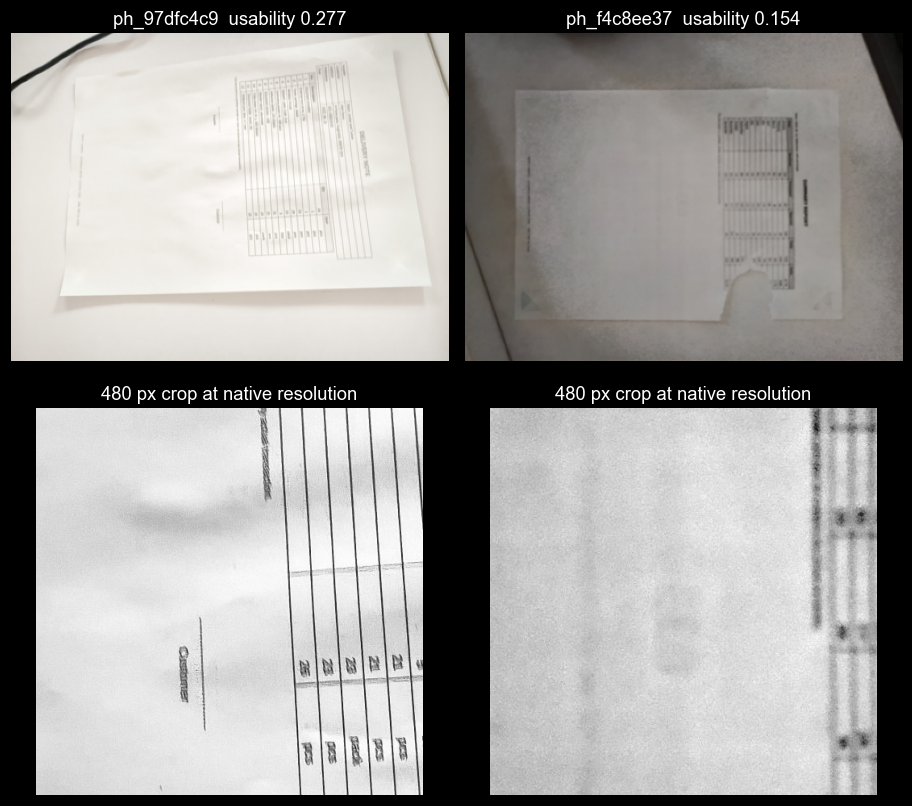

In [15]:
table = pd.Series(RESULTS, name="val RMSE (eval_ok rows)").to_frame()
table["vs constant"] = 1 - table["val RMSE (eval_ok rows)"] / RESULTS["constant"]
display(table)

display(pd.concat({"gradient boosting": evaluate.by_slice(val_df[ok], pred_gbm[ok], "family")["rmse"],
                   "mlp on pixels": evaluate.by_slice(val_df[ok], run["val_pred"][ok], "family")["rmse"],
                   "n": evaluate.by_slice(val_df[ok], pred_gbm[ok], "family")["n"]}, axis=1))

w = evaluate.worst(val_df[ok], run["val_pred"][ok], k=5)
display(w)
show_pair(w["image_id"].head(2).tolist(), w[config.TARGET].head(2).tolist())

### Commit

Commit the notebook with its outputs this once: the numbers are the
deliverable of the session. On your host, in this folder:

```bash
git add -A
git commit -m "lab 3: baseline and first network"
git push
```

Then run the cell below. `git status` must be empty and the commit must be
on `origin/main` before you leave.

In [16]:
!cd {config.ROOT} && git status --short && git log --oneline -3 && git branch -vv

 M notebooks/lab3_baseline.ipynb
 M src/train.py
02cf2cc (HEAD -> main, origin/main) changed cuda to mps
5bce4b3 lab 3: baseline and first network
947f52c lab 3: start
* main 02cf2cc [origin/main] changed cuda to mps


### Register on Moodle, before you leave

**This is your attendance for today.** Once the push has gone through, fill
in the task registration on Moodle, during the session:

https://edu.vik.bme.hu/mod/questionnaire/view.php?id=226967

It asks for the address of your public GitHub repository. No registration,
no attendance.

### Homework

1. **Early stopping, done honestly.** Make `train_mlp` keep the weights of
   the best epoch, chosen on a part of the *training* groups that you set
   aside for that purpose, and report the untouched validation score. Put the
   number in your `README.md` next to today's.
2. **`src/predict.py`.** Fill in the three TODO functions for the MLP
   checkpoint, so that one command turns a folder of photographs into a
   submission file. Test it on twenty training images and check that the
   numbers match `predict` in the loop.
3. **One feature of your own** for the baseline: look at its worst errors at
   native resolution and design a feature that would have seen what the seven
   did not. Report the number whether it improved or not.
4. **Claim or create your W&B account** if you ran anonymously today, and
   put the key in `.env`.